<a href="https://colab.research.google.com/github/AngeNana23/Assignment-15/blob/main/Assignment15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://colab.research.google.com/drive/1_1rQs8WbgP9Rh65gsFrVNYOVE9uitORs?usp=sharing

In [7]:
# ---------------------------
# 1. IMPORT LIBRARIES
# ---------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import shap

# ---------------------------
# 2. LOAD DATASET
# ---------------------------
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/bank-loan.csv')

print("Shape:", df.shape)
print(df.head())

# ---------------------------
# 3. DATA CLEANING
# ---------------------------

# Missing values
print(df.isnull().sum())

# Fill numeric missing values with median
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical missing values with mode
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)


Mounted at /content/drive
Shape: (850, 9)
   age  ed  employ  address  income  debtinc   creddebt   othdebt  default
0   41   3      17       12     176      9.3  11.359392  5.008608      1.0
1   27   1      10        6      31     17.3   1.362202  4.000798      0.0
2   40   1      15       14      55      5.5   0.856075  2.168925      0.0
3   41   1      15       14     120      2.9   2.658720  0.821280      0.0
4   24   2       2        0      28     17.3   1.787436  3.056564      1.0
age           0
ed            0
employ        0
address       0
income        0
debtinc       0
creddebt      0
othdebt       0
default     150
dtype: int64


/tmp/ipykernel_22746/3657519350.py:36: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


              age          ed      employ     address      income     debtinc  \
count  850.000000  850.000000  850.000000  850.000000  850.000000  850.000000   
mean    35.029412    1.710588    8.565882    8.371765   46.675294   10.171647   
std      8.041432    0.927784    6.777884    6.895016   38.543054    6.719441   
min     20.000000    1.000000    0.000000    0.000000   13.000000    0.100000   
25%     29.000000    1.000000    3.000000    3.000000   24.000000    5.100000   
50%     34.000000    1.000000    7.000000    7.000000   35.000000    8.700000   
75%     41.000000    2.000000   13.000000   12.000000   55.750000   13.800000   
max     56.000000    5.000000   33.000000   34.000000  446.000000   41.300000   

         creddebt     othdebt     default  
count  850.000000  850.000000  850.000000  
mean     1.576805    3.078789    0.215294  
std      2.125840    3.398803    0.411268  
min      0.011696    0.045584    0.000000  
25%      0.382176    1.045942    0.000000  
50%   

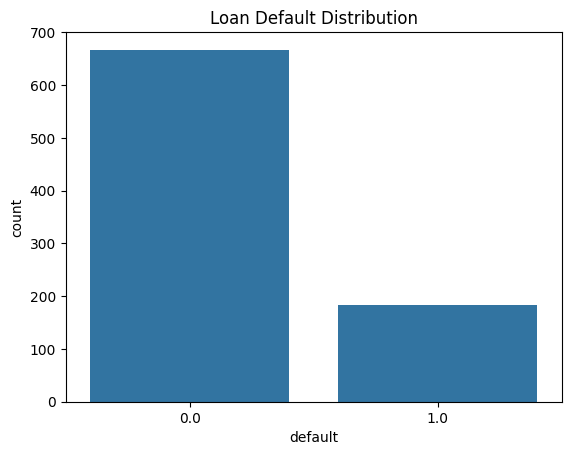

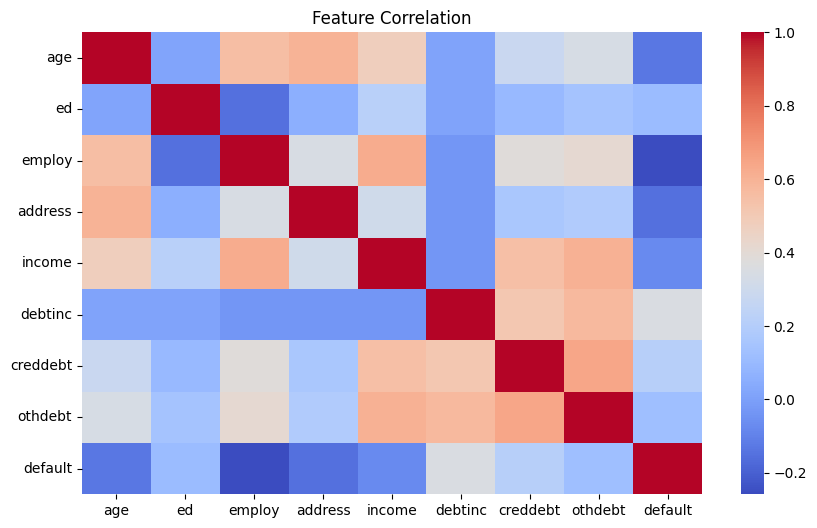

In [11]:
# ---------------------------
# 4. EXPLORATORY DATA ANALYSIS
# ---------------------------

print(df.describe())

# Target distribution
sns.countplot(x=df['default'])
plt.title("Loan Default Distribution")
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

# ---------------------------
# 5. ENCODING CATEGORICAL DATA
# ---------------------------
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# ---------------------------
# 6. FEATURE ENGINEERING
# ---------------------------

# Example feature: Debt per income ratio (if columns exist)
if 'LoanAmount' in df.columns and 'ApplicantIncome' in df.columns:
    df['Debt_Income_Ratio'] = df['LoanAmount'] / (df['ApplicantIncome'] + 1)


In [14]:
# ---------------------------
# 7. SPLIT DATA
# ---------------------------
X = df.drop('default', axis=1)
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------
# 8. FEATURE SCALING
# ---------------------------
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ---------------------------
# 9. MODEL TRAINING
# ---------------------------
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

Accuracy: 0.8176470588235294

Confusion Matrix:
 [[125   8]
 [ 23  14]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.84      0.94      0.89       133
         1.0       0.64      0.38      0.47        37

    accuracy                           0.82       170
   macro avg       0.74      0.66      0.68       170
weighted avg       0.80      0.82      0.80       170



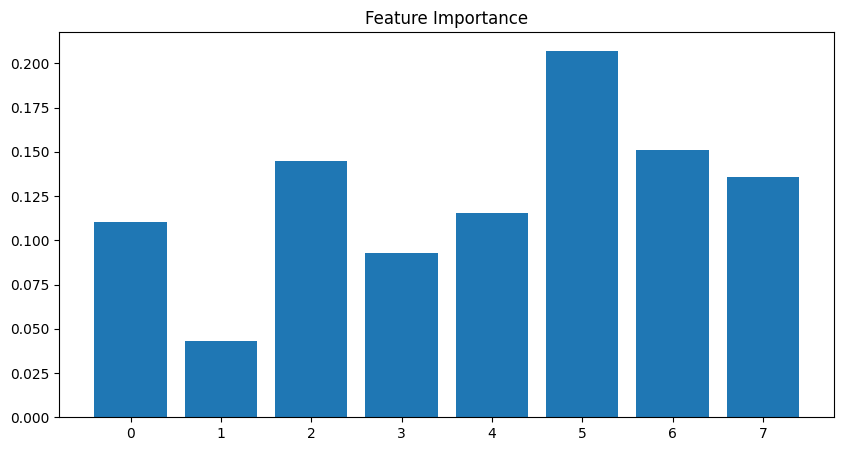

In [15]:
# ---------------------------
# 10. PREDICTIONS
# ---------------------------
y_pred = model.predict(X_test)

# ---------------------------
# 11. EVALUATION
# ---------------------------
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ---------------------------
# 12. FEATURE IMPORTANCE
# ---------------------------
importances = model.feature_importances_

plt.figure(figsize=(10,5))
plt.bar(range(len(importances)), importances)
plt.title("Feature Importance")
plt.show()


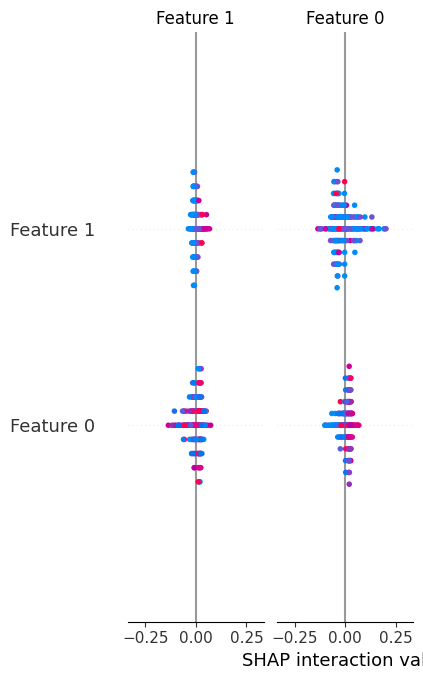

In [17]:
# ---------------------------
# 13. SHAP EXPLAINABILITY
# ---------------------------
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)
# ---------------------------
# 14. FAIRNESS ANALYSIS (Example: Gender)
# ---------------------------
if 'Gender' in df.columns:
    gender_groups = df['Gender'].unique()

    for g in gender_groups:
        idx = df['Gender'] == g
        X_g = X[idx]
        y_g = y[idx]

        if len(y_g) > 0:
            X_g_scaled = scaler.transform(X_g)
            preds = model.predict(X_g_scaled)
            acc = accuracy_score(y_g, preds)
            print(f"Accuracy for Gender {g}: {acc:.3f}")